# HW2 - Policy-Based RL (Single Notebook)

## 1. Imports

In [24]:
import math
import random
from dataclasses import dataclass

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

## 2. Reproducibility and configuration

In [25]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


@dataclass
class Config:
    env_name: str = "Ant-v5"
    gamma: float = 0.99
    lam: float = 0.95
    hidden_sizes: tuple = (128, 128)

    policy_lr: float = 3e-4
    value_lr: float = 1e-3

    episodes_per_batch: int = 10   # increased from 5
    total_episodes: int = 2000     # increased from 2000
    max_steps_per_episode: int = 1000

    ppo_clip_eps: float = 0.2
    ppo_policy_epochs: int = 10
    ppo_value_epochs: int = 10
    minibatch_size: int = 256

cfg_pg = Config(policy_lr=1e-4)
cfg_pgb = Config(policy_lr=1e-4, value_lr=1e-3)
cfg_ppo = Config(policy_lr=3e-4, value_lr=1e-3, total_episodes=2000)
cfg = cfg_ppo  # default
print("Configs ready.")


Using device: cpu
Configs ready.


## 3. Networks

In [26]:
def mlp(input_dim, hidden_sizes, output_dim, activation=nn.Tanh, output_activation=None):
    layers = []
    prev_dim = input_dim
    for h in hidden_sizes:
        layers.append(nn.Linear(prev_dim, h))
        layers.append(activation())
        prev_dim = h
    layers.append(nn.Linear(prev_dim, output_dim))
    if output_activation is not None:
        layers.append(output_activation())
    return nn.Sequential(*layers)


class GaussianPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes=(128, 128)):
        super().__init__()
        self.mu_net = mlp(obs_dim, hidden_sizes, act_dim, activation=nn.Tanh)
        self.log_std = nn.Parameter(torch.full((act_dim,), -1.0))

    def forward(self, obs):
        mu = self.mu_net(obs)
        std = torch.exp(self.log_std).expand_as(mu)
        return mu, std

    def get_dist(self, obs):
        mu, std = self.forward(obs)
        return Normal(mu, std)

    def sample_action(self, obs):
        dist = self.get_dist(obs)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        return action, log_prob

    def log_prob(self, obs, action):
        dist = self.get_dist(obs)
        return dist.log_prob(action).sum(dim=-1)

    def entropy(self, obs):
        dist = self.get_dist(obs)
        return dist.entropy().sum(dim=-1)


class ValueNetwork(nn.Module):
    def __init__(self, obs_dim, hidden_sizes=(128, 128)):
        super().__init__()
        self.v_net = mlp(obs_dim, hidden_sizes, 1, activation=nn.Tanh)

    def forward(self, obs):
        return self.v_net(obs).squeeze(-1)

## 4. Shared helpers

In [27]:
def make_env(env_name, seed=42):
    env = gym.make(env_name)
    env.reset(seed=seed)
    return env


class RunningNormalizer:
    """Tracks running mean and std for observation normalization."""
    def __init__(self, shape):
        self.mean = np.zeros(shape, dtype=np.float32)
        self.var = np.ones(shape, dtype=np.float32)
        self.count = 1e-4

    def update(self, x):
        x = np.array(x, dtype=np.float32)
        if x.ndim == 1:
            x = x[np.newaxis, :]
        batch_mean = np.mean(x, axis=0)
        batch_var = np.var(x, axis=0)
        batch_count = x.shape[0]
        total = self.count + batch_count
        delta = batch_mean - self.mean
        self.mean += delta * batch_count / total
        self.var = (self.var * self.count + batch_var * batch_count +
                    delta**2 * self.count * batch_count / total) / total
        self.count = total

    def normalize(self, x):
        return (x - self.mean) / (np.sqrt(self.var) + 1e-8)


def compute_reward_to_go(rewards, gamma=0.99):
    rtg = np.zeros(len(rewards), dtype=np.float32)
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        rtg[t] = running
    return rtg


def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    T = len(rewards)
    adv = np.zeros(T, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(T)):
        delta = rewards[t] + gamma * values[t + 1] * (1.0 - dones[t]) - values[t]
        gae = delta + gamma * lam * (1.0 - dones[t]) * gae
        adv[t] = gae
    returns = adv + values[:-1]
    return adv, returns


def moving_average(x, window=20):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_learning_curve(returns, label="Return", window=20):
    plt.figure(figsize=(8, 5))
    plt.plot(returns, alpha=0.35, label=f"{label} raw")
    if len(returns) >= window:
        plt.plot(
            np.arange(window - 1, len(returns)),
            moving_average(returns, window),
            label=f"{label} moving avg ({window})",
        )
    plt.xlabel("Episode")
    plt.ylabel("Undiscounted Return")
    plt.title(label)
    plt.grid(True)
    plt.legend()
    plt.show()


## 5. Trajectory collection

In [28]:
def collect_batch(env, policy, episodes_per_batch, gamma, max_steps):
    batch_obs = []
    batch_actions = []
    batch_rewards = []
    batch_dones = []
    batch_log_probs = []
    batch_episode_returns = []
    batch_episode_lengths = []

    for _ in range(episodes_per_batch):
        obs, _ = env.reset()
        done = False
        ep_rewards = []
        ep_return = 0.0
        steps = 0

        while not done and steps < max_steps:
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                action_t, log_prob_t = policy.sample_action(obs_t)

            action = action_t.squeeze(0).cpu().numpy()
            action = np.clip(action, env.action_space.low, env.action_space.high)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            batch_obs.append(obs)
            batch_actions.append(action)
            batch_rewards.append(reward)
            batch_dones.append(float(done))
            batch_log_probs.append(log_prob_t.item())

            ep_rewards.append(reward)
            ep_return += reward
            steps += 1
            obs = next_obs

        batch_episode_returns.append(ep_return)
        batch_episode_lengths.append(steps)

    batch = {
        "obs": np.array(batch_obs, dtype=np.float32),
        "actions": np.array(batch_actions, dtype=np.float32),
        "rewards": np.array(batch_rewards, dtype=np.float32),
        "dones": np.array(batch_dones, dtype=np.float32),
        "old_log_probs": np.array(batch_log_probs, dtype=np.float32),
        "episode_returns": batch_episode_returns,
        "episode_lengths": batch_episode_lengths,
    }
    return batch

# Question 1 - Algorithm 1: Vanilla Policy Gradient (`pg`)

In [29]:
def train_pg(config: Config):
    env = make_env(config.env_name, seed=42)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]

    policy = GaussianPolicy(obs_dim, act_dim, config.hidden_sizes).to(device)
    policy_optimizer = optim.Adam(policy.parameters(), lr=config.policy_lr)
    obs_normalizer = RunningNormalizer(obs_dim)

    episode_returns_history = []
    episodes_done = 0

    while episodes_done < config.total_episodes:
        batch = collect_batch(
            env=env,
            policy=policy,
            episodes_per_batch=config.episodes_per_batch,
            gamma=config.gamma,
            max_steps=config.max_steps_per_episode,
        )

        # Update and normalize observations
        obs_normalizer.update(batch["obs"])
        obs_norm = obs_normalizer.normalize(batch["obs"])

        obs_t = torch.tensor(obs_norm, dtype=torch.float32, device=device)
        actions_t = torch.tensor(batch["actions"], dtype=torch.float32, device=device)

        rtg_list = []
        idx = 0
        for ep_len in batch["episode_lengths"]:
            ep_rewards = batch["rewards"][idx: idx + ep_len]
            ep_rtg = compute_reward_to_go(ep_rewards, gamma=config.gamma)
            rtg_list.append(ep_rtg)
            idx += ep_len
        returns_t = torch.tensor(np.concatenate(rtg_list), dtype=torch.float32, device=device)

        returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

        log_probs = policy.log_prob(obs_t, actions_t)
        policy_loss = -(log_probs * returns_t).mean()

        policy_optimizer.zero_grad()
        policy_loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), max_norm=0.5)
        policy_optimizer.step()

        episode_returns_history.extend(batch["episode_returns"])
        episodes_done += len(batch["episode_returns"])

        if episodes_done % 50 == 0:
            print(
                f"[PG] Episodes: {episodes_done:4d} | "
                f"AvgReturn(last 50): {np.mean(episode_returns_history[-50:]):8.2f}"
            )

    env.close()
    return policy, episode_returns_history[:config.total_episodes]


### Run Vanilla Policy Gradient

[PG] Episodes:   50 | AvgReturn(last 50):   174.50
[PG] Episodes:  100 | AvgReturn(last 50):   158.66
[PG] Episodes:  150 | AvgReturn(last 50):   193.51
[PG] Episodes:  200 | AvgReturn(last 50):   129.87
[PG] Episodes:  250 | AvgReturn(last 50):   124.81
[PG] Episodes:  300 | AvgReturn(last 50):   153.12
[PG] Episodes:  350 | AvgReturn(last 50):   142.13
[PG] Episodes:  400 | AvgReturn(last 50):   155.77
[PG] Episodes:  450 | AvgReturn(last 50):   161.62
[PG] Episodes:  500 | AvgReturn(last 50):   159.07
[PG] Episodes:  550 | AvgReturn(last 50):   159.69
[PG] Episodes:  600 | AvgReturn(last 50):   179.29
[PG] Episodes:  650 | AvgReturn(last 50):   192.46
[PG] Episodes:  700 | AvgReturn(last 50):   183.39
[PG] Episodes:  750 | AvgReturn(last 50):   203.98
[PG] Episodes:  800 | AvgReturn(last 50):   214.57
[PG] Episodes:  850 | AvgReturn(last 50):   236.16
[PG] Episodes:  900 | AvgReturn(last 50):   215.31
[PG] Episodes:  950 | AvgReturn(last 50):   221.59
[PG] Episodes: 1000 | AvgReturn

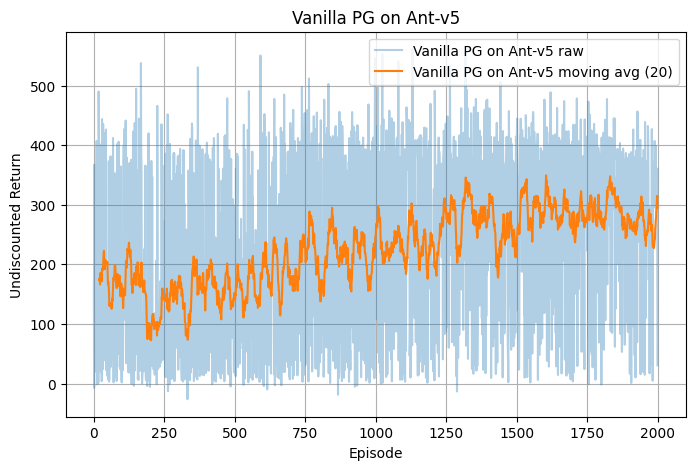

In [17]:
pg_policy, pg_returns = train_pg(cfg_pg)
plot_learning_curve(pg_returns, label="Vanilla PG on Ant-v5", window=20)


# Question 1 - Algorithm 2: Policy Gradient with Baseline (`pgb`)

In [18]:
def train_pgb(config: Config):
    env = make_env(config.env_name, seed=42)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]

    policy = GaussianPolicy(obs_dim, act_dim, config.hidden_sizes).to(device)
    value_fn = ValueNetwork(obs_dim, config.hidden_sizes).to(device)

    policy_optimizer = optim.Adam(policy.parameters(), lr=config.policy_lr)
    value_optimizer = optim.Adam(value_fn.parameters(), lr=config.value_lr)
    obs_normalizer = RunningNormalizer(obs_dim)

    episode_returns_history = []
    episodes_done = 0

    while episodes_done < config.total_episodes:
        batch = collect_batch(
            env=env,
            policy=policy,
            episodes_per_batch=config.episodes_per_batch,
            gamma=config.gamma,
            max_steps=config.max_steps_per_episode,
        )

        obs_normalizer.update(batch["obs"])
        obs_norm = obs_normalizer.normalize(batch["obs"])

        obs_t = torch.tensor(obs_norm, dtype=torch.float32, device=device)
        actions_t = torch.tensor(batch["actions"], dtype=torch.float32, device=device)

        rtg_list = []
        idx = 0
        for ep_len in batch["episode_lengths"]:
            ep_rewards = batch["rewards"][idx: idx + ep_len]
            ep_rtg = compute_reward_to_go(ep_rewards, gamma=config.gamma)
            rtg_list.append(ep_rtg)
            idx += ep_len
        returns_t = torch.tensor(np.concatenate(rtg_list), dtype=torch.float32, device=device)

        values_t = value_fn(obs_t)
        advantages_t = returns_t - values_t.detach()
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)

        log_probs = policy.log_prob(obs_t, actions_t)
        policy_loss = -(log_probs * advantages_t).mean()

        value_loss = ((value_fn(obs_t) - returns_t) ** 2).mean()

        policy_optimizer.zero_grad()
        policy_loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), max_norm=0.5)
        policy_optimizer.step()

        value_optimizer.zero_grad()
        value_loss.backward()
        value_optimizer.step()

        episode_returns_history.extend(batch["episode_returns"])
        episodes_done += len(batch["episode_returns"])

        if episodes_done % 50 == 0:
            print(
                f"[PGB] Episodes: {episodes_done:4d} | "
                f"AvgReturn(last 50): {np.mean(episode_returns_history[-50:]):8.2f}"
            )

    env.close()
    return policy, value_fn, episode_returns_history[:config.total_episodes]


### Run Policy Gradient with Baseline

[PGB] Episodes:   50 | AvgReturn(last 50):   151.33
[PGB] Episodes:  100 | AvgReturn(last 50):   141.92
[PGB] Episodes:  150 | AvgReturn(last 50):   121.11
[PGB] Episodes:  200 | AvgReturn(last 50):   133.21
[PGB] Episodes:  250 | AvgReturn(last 50):   141.84
[PGB] Episodes:  300 | AvgReturn(last 50):   168.85
[PGB] Episodes:  350 | AvgReturn(last 50):   180.43
[PGB] Episodes:  400 | AvgReturn(last 50):   171.35
[PGB] Episodes:  450 | AvgReturn(last 50):   128.29
[PGB] Episodes:  500 | AvgReturn(last 50):   202.98
[PGB] Episodes:  550 | AvgReturn(last 50):   208.72
[PGB] Episodes:  600 | AvgReturn(last 50):   199.77
[PGB] Episodes:  650 | AvgReturn(last 50):   185.19
[PGB] Episodes:  700 | AvgReturn(last 50):   223.88
[PGB] Episodes:  750 | AvgReturn(last 50):   238.04
[PGB] Episodes:  800 | AvgReturn(last 50):   228.30
[PGB] Episodes:  850 | AvgReturn(last 50):   177.58
[PGB] Episodes:  900 | AvgReturn(last 50):   236.18
[PGB] Episodes:  950 | AvgReturn(last 50):   229.99
[PGB] Episod

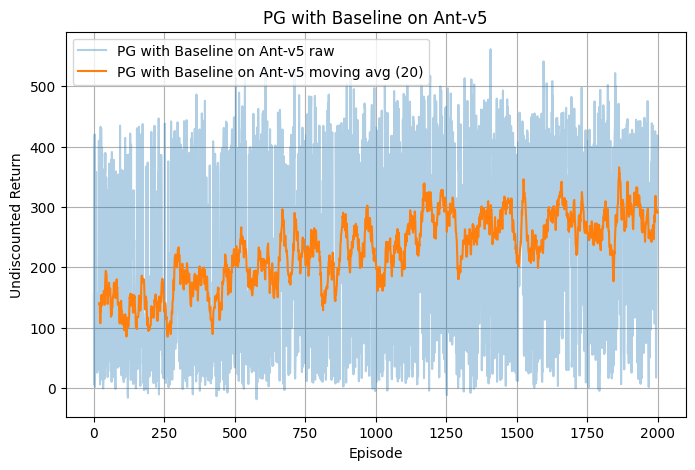

In [19]:
pgb_policy, pgb_value, pgb_returns = train_pgb(cfg_pgb)
plot_learning_curve(pgb_returns, label="PG with Baseline on Ant-v5", window=20)


# Question 1 - Algorithm 3: Proximal Policy Optimization (`ppo`)

In [20]:
def collect_batch_ppo(env, policy, value_fn, obs_normalizer, episodes_per_batch, gamma, lam, max_steps):
    obs_buf = []
    actions_buf = []
    rewards_buf = []
    dones_buf = []
    values_buf = []
    log_probs_buf = []
    returns_per_episode = []
    advantages_buf = []
    returns_buf = []

    for _ in range(episodes_per_batch):
        obs, _ = env.reset()
        done = False
        ep_return = 0.0
        steps = 0

        ep_obs = []
        ep_actions = []
        ep_rewards = []
        ep_dones = []
        ep_values = []
        ep_log_probs = []

        while not done and steps < max_steps:
            obs_norm = obs_normalizer.normalize(obs)
            obs_t = torch.tensor(obs_norm, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                value = value_fn(obs_t).item()
                action_t, log_prob_t = policy.sample_action(obs_t)

            action = action_t.squeeze(0).cpu().numpy()
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            ep_obs.append(obs)
            ep_actions.append(action)
            ep_rewards.append(reward)
            ep_dones.append(float(done))
            ep_values.append(value)
            ep_log_probs.append(log_prob_t.item())

            ep_return += reward
            steps += 1
            obs = next_obs

        with torch.no_grad():
            if done:
                final_value = 0.0
            else:
                obs_norm = obs_normalizer.normalize(obs)
                final_value = value_fn(
                    torch.tensor(obs_norm, dtype=torch.float32, device=device).unsqueeze(0)
                ).item()

        ep_values_plus = np.array(ep_values + [final_value], dtype=np.float32)
        ep_advantages, ep_returns = compute_gae(
            rewards=np.array(ep_rewards, dtype=np.float32),
            values=ep_values_plus,
            dones=np.array(ep_dones, dtype=np.float32),
            gamma=gamma,
            lam=lam,
        )

        obs_buf.extend(ep_obs)
        actions_buf.extend(ep_actions)
        rewards_buf.extend(ep_rewards)
        dones_buf.extend(ep_dones)
        values_buf.extend(ep_values)
        log_probs_buf.extend(ep_log_probs)
        returns_per_episode.append(ep_return)
        advantages_buf.extend(ep_advantages)
        returns_buf.extend(ep_returns)

    # Update normalizer with all collected obs
    obs_normalizer.update(np.array(obs_buf, dtype=np.float32))

    # Normalize obs for training
    obs_normalized = obs_normalizer.normalize(np.array(obs_buf, dtype=np.float32))

    batch = {
        "obs": obs_normalized,
        "actions": np.array(actions_buf, dtype=np.float32),
        "rewards": np.array(rewards_buf, dtype=np.float32),
        "dones": np.array(dones_buf, dtype=np.float32),
        "values": np.array(values_buf, dtype=np.float32),
        "old_log_probs": np.array(log_probs_buf, dtype=np.float32),
        "advantages": np.array(advantages_buf, dtype=np.float32),
        "returns": np.array(returns_buf, dtype=np.float32),
        "episode_returns": returns_per_episode,
    }
    return batch


def minibatch_indices(n, batch_size):
    indices = np.arange(n)
    np.random.shuffle(indices)
    for start in range(0, n, batch_size):
        yield indices[start:start + batch_size]


def train_ppo(config: Config):
    env = make_env(config.env_name, seed=42)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]

    policy = GaussianPolicy(obs_dim, act_dim, config.hidden_sizes).to(device)
    value_fn = ValueNetwork(obs_dim, config.hidden_sizes).to(device)

    policy_optimizer = optim.Adam(policy.parameters(), lr=config.policy_lr)
    value_optimizer = optim.Adam(value_fn.parameters(), lr=config.value_lr)
    obs_normalizer = RunningNormalizer(obs_dim)

    episode_returns_history = []
    episodes_done = 0

    while episodes_done < config.total_episodes:
        batch = collect_batch_ppo(
            env=env,
            policy=policy,
            value_fn=value_fn,
            obs_normalizer=obs_normalizer,
            episodes_per_batch=config.episodes_per_batch,
            gamma=config.gamma,
            lam=config.lam,
            max_steps=config.max_steps_per_episode,
        )

        obs_t = torch.tensor(batch["obs"], dtype=torch.float32, device=device)
        actions_t = torch.tensor(batch["actions"], dtype=torch.float32, device=device)
        old_log_probs_t = torch.tensor(batch["old_log_probs"], dtype=torch.float32, device=device)
        advantages_t = torch.tensor(batch["advantages"], dtype=torch.float32, device=device)
        returns_t = torch.tensor(batch["returns"], dtype=torch.float32, device=device)

        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)
        n = len(obs_t)

        for _ in range(config.ppo_policy_epochs):
            for mb_idx in minibatch_indices(n, config.minibatch_size):
                mb_obs = obs_t[mb_idx]
                mb_actions = actions_t[mb_idx]
                mb_old_log_probs = old_log_probs_t[mb_idx]
                mb_advantages = advantages_t[mb_idx]

                new_log_probs = policy.log_prob(mb_obs, mb_actions)
                ratio = torch.exp(new_log_probs - mb_old_log_probs)

                unclipped = ratio * mb_advantages
                clipped = torch.clamp(
                    ratio,
                    1.0 - config.ppo_clip_eps,
                    1.0 + config.ppo_clip_eps,
                ) * mb_advantages

                policy_loss = -torch.min(unclipped, clipped).mean()

                policy_optimizer.zero_grad()
                policy_loss.backward()
                nn.utils.clip_grad_norm_(policy.parameters(), max_norm=0.5)
                policy_optimizer.step()

        for _ in range(config.ppo_value_epochs):
            for mb_idx in minibatch_indices(n, config.minibatch_size):
                mb_obs = obs_t[mb_idx]
                mb_returns = returns_t[mb_idx]

                value_loss = ((value_fn(mb_obs) - mb_returns) ** 2).mean()

                value_optimizer.zero_grad()
                value_loss.backward()
                value_optimizer.step()

        episode_returns_history.extend(batch["episode_returns"])
        episodes_done += len(batch["episode_returns"])

        if episodes_done % 50 == 0:
            print(
                f"[PPO] Episodes: {episodes_done:4d} | "
                f"AvgReturn(last 50): {np.mean(episode_returns_history[-50:]):8.2f}"
            )

    env.close()
    return policy, value_fn, episode_returns_history[:config.total_episodes]


### Run PPO

[PPO] Episodes:   50 | AvgReturn(last 50):   241.06
[PPO] Episodes:  100 | AvgReturn(last 50):   300.67
[PPO] Episodes:  150 | AvgReturn(last 50):   247.55
[PPO] Episodes:  200 | AvgReturn(last 50):   338.30
[PPO] Episodes:  250 | AvgReturn(last 50):   396.44
[PPO] Episodes:  300 | AvgReturn(last 50):   477.40
[PPO] Episodes:  350 | AvgReturn(last 50):   535.48
[PPO] Episodes:  400 | AvgReturn(last 50):   637.55
[PPO] Episodes:  450 | AvgReturn(last 50):   627.33
[PPO] Episodes:  500 | AvgReturn(last 50):   683.28
[PPO] Episodes:  550 | AvgReturn(last 50):   689.14
[PPO] Episodes:  600 | AvgReturn(last 50):   784.99
[PPO] Episodes:  650 | AvgReturn(last 50):   822.70
[PPO] Episodes:  700 | AvgReturn(last 50):   940.58
[PPO] Episodes:  750 | AvgReturn(last 50):  1018.54
[PPO] Episodes:  800 | AvgReturn(last 50):   824.89
[PPO] Episodes:  850 | AvgReturn(last 50):   977.97
[PPO] Episodes:  900 | AvgReturn(last 50):  1056.85
[PPO] Episodes:  950 | AvgReturn(last 50):  1023.23
[PPO] Episod

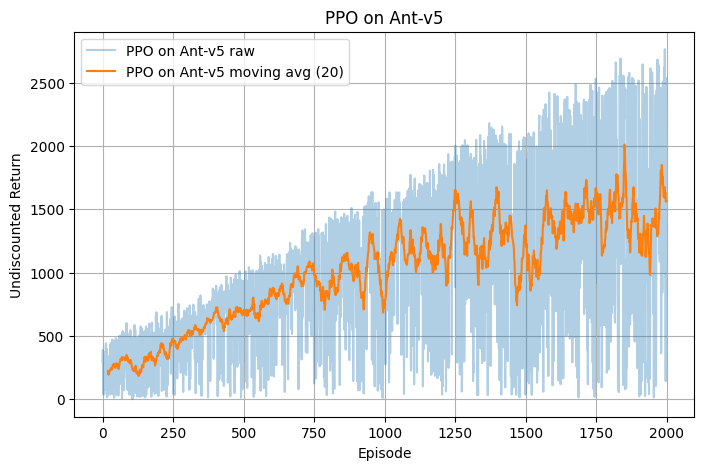

In [21]:
ppo_policy, ppo_value, ppo_returns = train_ppo(cfg_ppo)
plot_learning_curve(ppo_returns, label="PPO on Ant-v5", window=20)


# Question 2: Combined Learning Curves

Saved → plots/learning_curves_individual.png


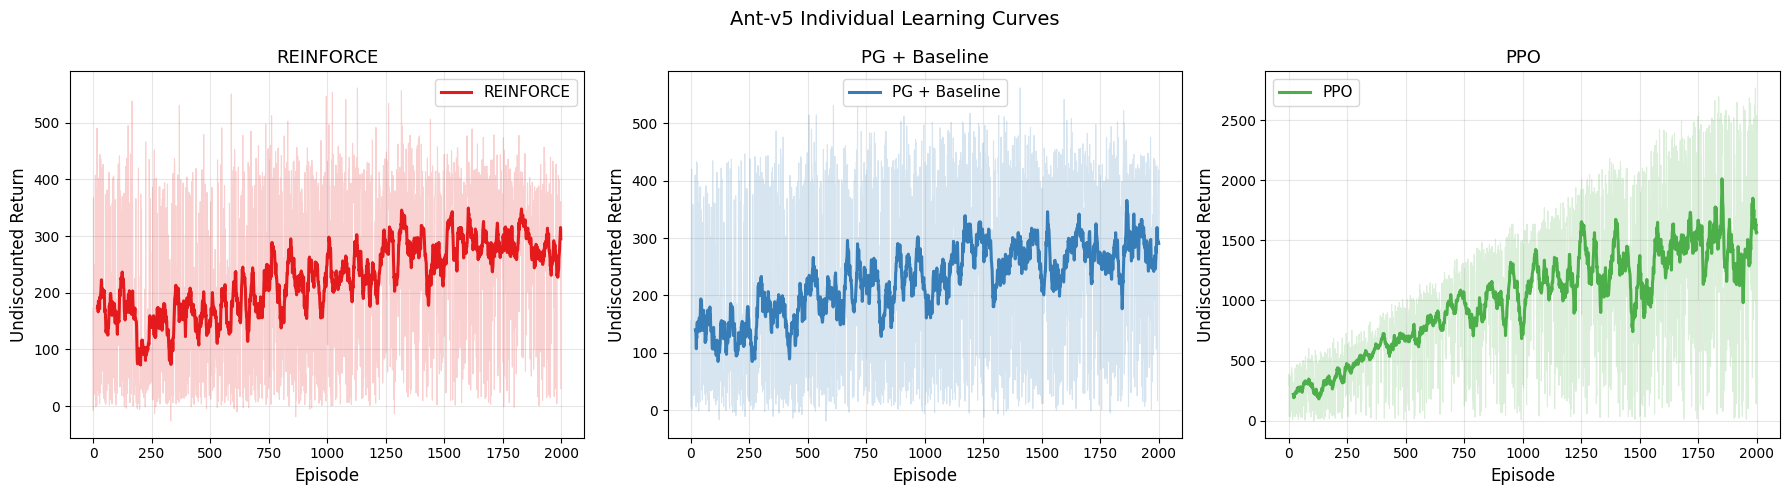

In [34]:
# Individual learning curves for each algorithm
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

WINDOW = 20

algorithms = [
    ('REINFORCE', pg_returns, '#e41a1c'),
    ('PG + Baseline', pgb_returns, '#377eb8'),
    ('PPO', ppo_returns, '#4daf4a'),
]

for ax, (label, rets, color) in zip(axes, algorithms):
    rets = np.array(rets)
    ax.plot(range(len(rets)), rets, color=color, alpha=0.2, linewidth=0.8)
    if len(rets) >= WINDOW:
        smoothed = np.convolve(rets, np.ones(WINDOW) / WINDOW, mode='valid')
        ax.plot(np.arange(WINDOW - 1, len(rets)), smoothed,
                color=color, linewidth=2.2, label=label)
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Undiscounted Return', fontsize=12)
    ax.set_title(label, fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

plt.suptitle('Ant-v5 Individual Learning Curves', fontsize=14)
plt.tight_layout()
plt.savefig('plots/learning_curves_individual.png', dpi=150)
print('Saved → plots/learning_curves_individual.png')
plt.show()

Saved → plots/learning_curves_q2.png


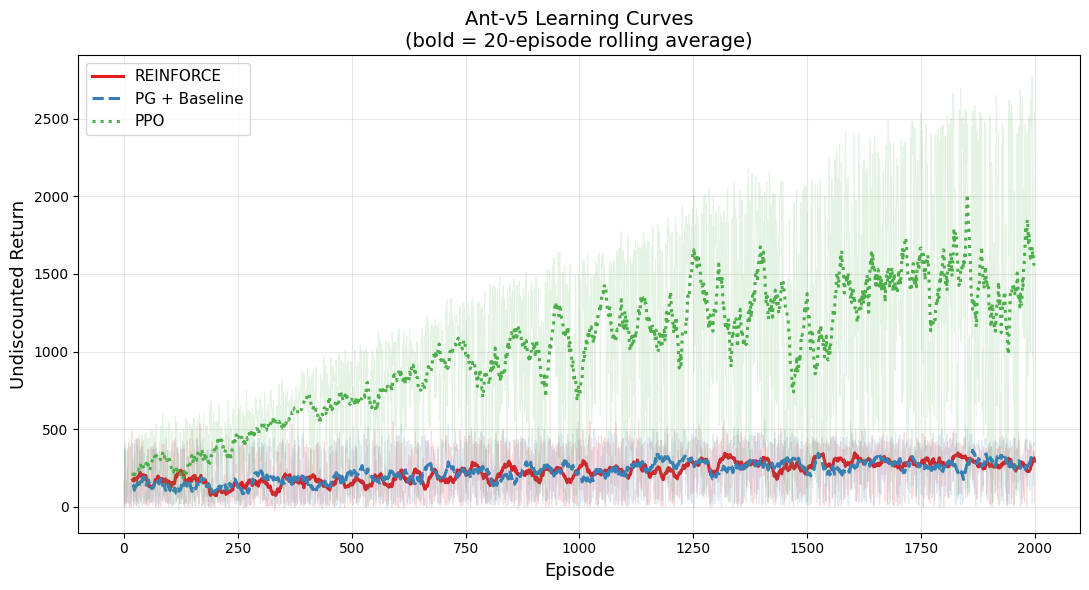

In [22]:
WINDOW = 20

all_returns = {
    'REINFORCE':     (pg_returns,  '#e41a1c', '-'),
    'PG + Baseline': (pgb_returns, '#377eb8', '--'),
    'PPO':           (ppo_returns, '#4daf4a', ':'),
}

fig, ax = plt.subplots(figsize=(11, 6))

for label, (rets, color, ls) in all_returns.items():
    rets = np.array(rets)
    ax.plot(range(len(rets)), rets, color=color, alpha=0.15, linewidth=0.8)
    if len(rets) >= WINDOW:
        smoothed = np.convolve(rets, np.ones(WINDOW) / WINDOW, mode='valid')
        ax.plot(np.arange(WINDOW - 1, len(rets)), smoothed,
                color=color, linestyle=ls, linewidth=2.2, label=label)

ax.set_xlabel('Episode', fontsize=13)
ax.set_ylabel('Undiscounted Return', fontsize=13)
ax.set_title('Ant-v5 Learning Curves\n(bold = 20-episode rolling average)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
import os; os.makedirs('plots', exist_ok=True)
plt.savefig('plots/learning_curves_q2.png', dpi=150)
print('Saved → plots/learning_curves_q2.png')
plt.show()


# Question 3: PPO Hyperparameter Sweep

In [32]:
# ── Question 3: PPO Learning Rate Sweep ──────────────────────────────────────
# Q2 uses policy_lr=3e-4, so we pick 3 different values here
LR_SWEEP = [1e-4, 1e-3, 3e-3]
sweep_returns = {}

for lr in LR_SWEEP:
    label = f'lr={lr:.0e}'
    print(f'\n── PPO sweep: {label} ──')
    cfg_sweep = Config(
        policy_lr=lr,
        value_lr=1e-3,
        episodes_per_batch=10,
        total_episodes=2000,
    )
    _, _, rets = train_ppo(cfg_sweep)
    sweep_returns[label] = rets

print('\nSweep complete.')



── PPO sweep: lr=1e-04 ──
[PPO] Episodes:   50 | AvgReturn(last 50):   164.79
[PPO] Episodes:  100 | AvgReturn(last 50):   198.94
[PPO] Episodes:  150 | AvgReturn(last 50):   208.00
[PPO] Episodes:  200 | AvgReturn(last 50):   291.79
[PPO] Episodes:  250 | AvgReturn(last 50):   365.86
[PPO] Episodes:  300 | AvgReturn(last 50):   421.20
[PPO] Episodes:  350 | AvgReturn(last 50):   367.66
[PPO] Episodes:  400 | AvgReturn(last 50):   460.85
[PPO] Episodes:  450 | AvgReturn(last 50):   524.87
[PPO] Episodes:  500 | AvgReturn(last 50):   510.96
[PPO] Episodes:  550 | AvgReturn(last 50):   574.24
[PPO] Episodes:  600 | AvgReturn(last 50):   609.01
[PPO] Episodes:  650 | AvgReturn(last 50):   638.42
[PPO] Episodes:  700 | AvgReturn(last 50):   661.54
[PPO] Episodes:  750 | AvgReturn(last 50):   725.57
[PPO] Episodes:  800 | AvgReturn(last 50):   841.30
[PPO] Episodes:  850 | AvgReturn(last 50):   805.55
[PPO] Episodes:  900 | AvgReturn(last 50):   855.90
[PPO] Episodes:  950 | AvgReturn(last

Saved → plots/learning_curves_q3_individual.png


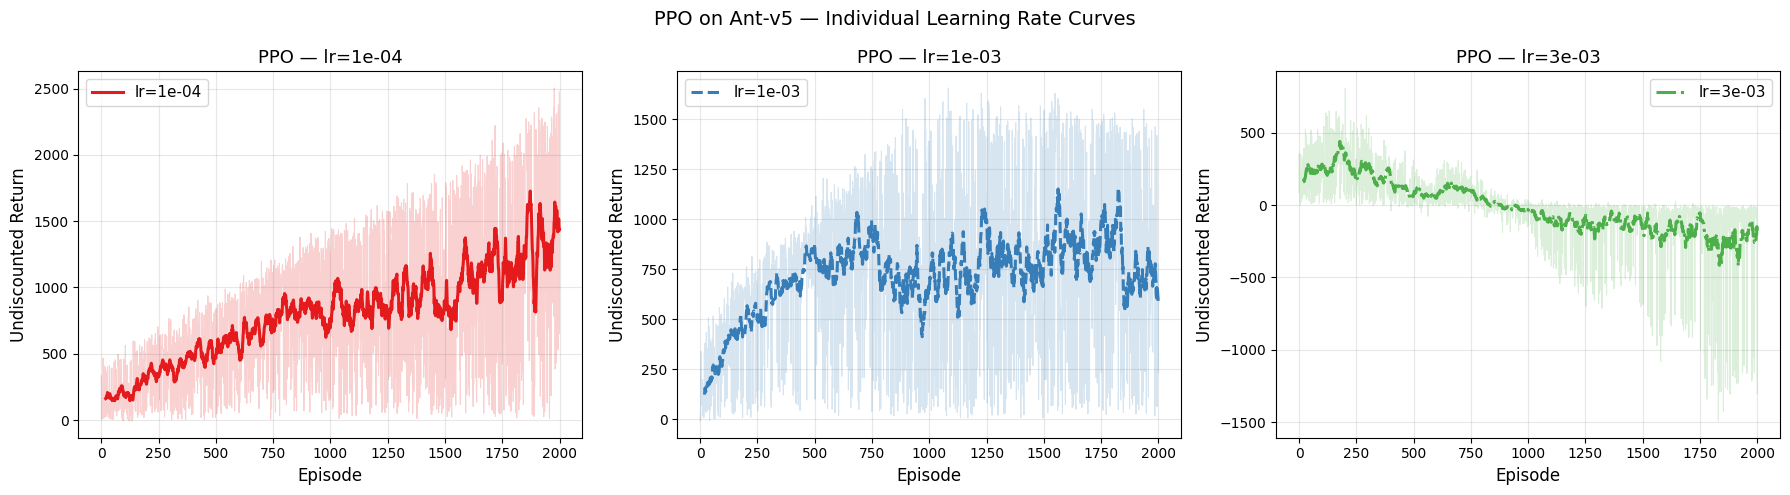

In [36]:
# Q3 - Individual plots for each lr setting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_sweep = ['#e41a1c', '#377eb8', '#4daf4a']
ls_sweep = ['-', '--', '-.']
WINDOW = 20

for ax, (label, rets), color, ls in zip(axes, sweep_returns.items(), colors_sweep, ls_sweep):
    rets = np.array(rets)
    ax.plot(range(len(rets)), rets, color=color, alpha=0.2, linewidth=0.8)
    if len(rets) >= WINDOW:
        smoothed = np.convolve(rets, np.ones(WINDOW) / WINDOW, mode='valid')
        ax.plot(np.arange(WINDOW - 1, len(rets)), smoothed,
                color=color, linestyle=ls, linewidth=2.2, label=label)
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Undiscounted Return', fontsize=12)
    ax.set_title(f'PPO — {label}', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

plt.suptitle('PPO on Ant-v5 — Individual Learning Rate Curves', fontsize=14)
plt.tight_layout()
plt.savefig('plots/learning_curves_q3_individual.png', dpi=150)
print('Saved → plots/learning_curves_q3_individual.png')
plt.show()

Saved → plots/learning_curves_q3.png


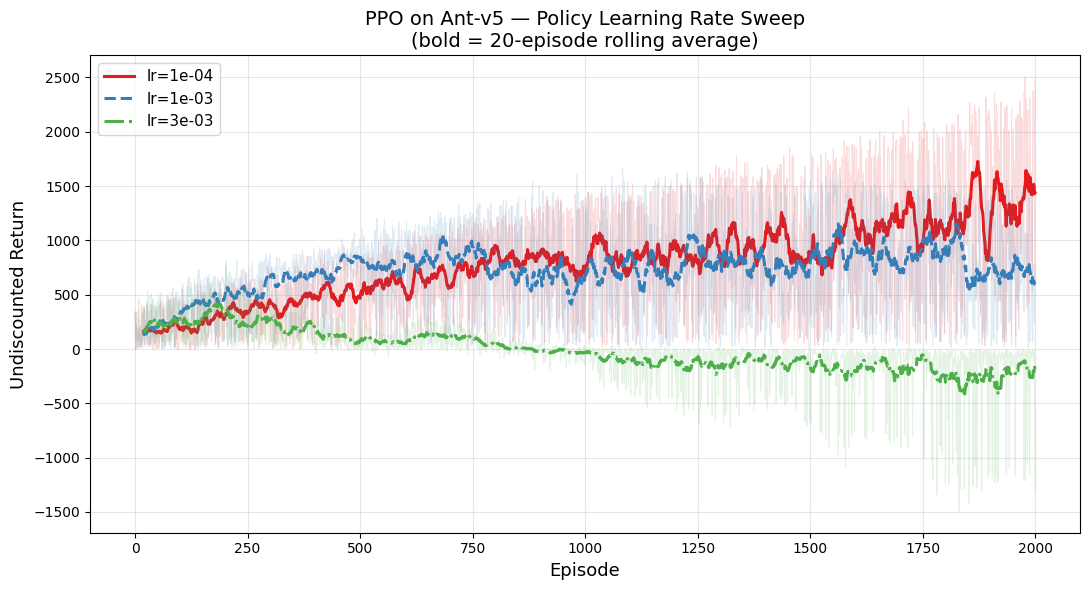


Sweep summary (last 100 episodes):
Setting         Mean Return   Max Return
----------------------------------------
lr=1e-04             1393.7       2504.2
lr=1e-03              684.7       1657.0
lr=3e-03             -221.4        808.8


In [33]:
# ── Question 3: Plot ─────────────────────────────────────────────────────────
WINDOW = 20
colors_sweep = ['#e41a1c', '#377eb8', '#4daf4a']
ls_sweep = ['-', '--', '-.']

fig, ax = plt.subplots(figsize=(11, 6))

for (label, rets), color, ls in zip(sweep_returns.items(), colors_sweep, ls_sweep):
    rets = np.array(rets)
    ax.plot(range(len(rets)), rets, color=color, alpha=0.15, linewidth=0.8)
    if len(rets) >= WINDOW:
        smoothed = np.convolve(rets, np.ones(WINDOW) / WINDOW, mode='valid')
        ax.plot(np.arange(WINDOW - 1, len(rets)), smoothed,
                color=color, linestyle=ls, linewidth=2.2, label=label)

ax.set_xlabel('Episode', fontsize=13)
ax.set_ylabel('Undiscounted Return', fontsize=13)
ax.set_title('PPO on Ant-v5 — Policy Learning Rate Sweep\n(bold = 20-episode rolling average)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/learning_curves_q3.png', dpi=150)
print('Saved → plots/learning_curves_q3.png')
plt.show()

print('\nSweep summary (last 100 episodes):')
print(f'{"Setting":<12} {"Mean Return":>14} {"Max Return":>12}')
print('-' * 40)
for label, rets in sweep_returns.items():
    rets = np.array(rets)
    print(f'{label:<12} {np.mean(rets[-100:]):>14.1f} {np.max(rets):>12.1f}')
